In [ ]:
#@title 0) setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import itertools, random, time
import copy

# Reproducibility
SEED = 42
def resetRandom():
  torch.manual_seed(SEED)
  np.random.seed(SEED)
  random.seed(SEED)
resetRandom()

# training time optimization
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 1) MLP: A * B % C (A,B between 0..99, C between 0..19)

## 1.1) Dataset

In [ ]:
def one_hot(n, num_classes=100):
    # One-hot encode a single integer.
    v = np.zeros(num_classes, dtype=np.float32)
    v[n] = 1.0
    return v

# ── Generate all 190,000 input pairs ──
pairs = list(itertools.product(range(100), range(100), range(19)))
random.shuffle(pairs)

X_all, y_all = [], []
for a, b, c in pairs:
    x = np.concatenate([one_hot(a), one_hot(b), one_hot(c, 19)])   # 220-dim
    y = (a * b) % (c+1)
    X_all.append(x)
    y_all.append(y)

X_all = np.array(X_all)
y_all = np.array(y_all)

# 80-20 split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# DataLoaders — mini-batch (full-batch would be 8K samples)
BATCH_SIZE = 256
train_ds = TensorDataset(torch.tensor(X_train).to(device), torch.tensor(y_train, dtype=torch.long).to(device))
test_ds  = TensorDataset(torch.tensor(X_test).to(device),  torch.tensor(y_test, dtype=torch.long).to(device))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} samples  |  Test: {len(test_ds):,} samples")
print(f"Input dim: {X_train.shape[1]}  |  Output classes: {len(np.unique(y_all))}")
print(f"Label distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train: 152,000 samples  |  Test: 38,000 samples
Input dim: 219  |  Output classes: 19
Label distribution (train): {np.int64(0): np.int64(51411), np.int64(1): np.int64(11977), np.int64(2): np.int64(14363), np.int64(3): np.int64(10413), np.int64(4): np.int64(11615), np.int64(5): np.int64(6717), np.int64(6): np.int64(10053), np.int64(7): np.int64(4823), np.int64(8): np.int64(6869), np.int64(9): np.int64(4650), np.int64(10): np.int64(4769), np.int64(11): np.int64(2542), np.int64(12): np.int64(4452), np.int64(13): np.int64(1747), np.int64(14): np.int64(2023), np.int64(15): np.int64(1374), np.int64(16): np.int64(1254), np.int64(17): np.int64(538), np.int64(18): np.int64(410)}


## 1.2) DNN: 219-> 32 x 256 w/ ReLU+Residuals ->19

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim=220,
                 output_dim=19, hidden_dim=256,
                 layer_depth=32, has_residuals=False):
        super().__init__()
        self.has_residuals = has_residuals
        self.proj_in = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(layer_depth):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.proj_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.proj_in(x))
        for layer in self.layers:
            if self.has_residuals:
                x = x + F.relu(layer(x))
            else:
                x = F.relu(layer(x))
        return self.proj_out(x)

model = DNN().to(device)
print(model)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Per-layer shapes:")
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"  {name:30s}  {str(list(param.shape)):>15s}  ({param.numel():>6,} params)")


DNN(
  (proj_in): Linear(in_features=220, out_features=256, bias=True)
  (layers): ModuleList(
    (0-31): 32 x Linear(in_features=256, out_features=256, bias=True)
  )
  (proj_out): Linear(in_features=256, out_features=20, bias=True)
)
Total parameters: 2,167,060
Per-layer shapes:
  proj_in.weight                       [256, 220]  (56,320 params)
  layers.0.weight                      [256, 256]  (65,536 params)
  layers.1.weight                      [256, 256]  (65,536 params)
  layers.2.weight                      [256, 256]  (65,536 params)
  layers.3.weight                      [256, 256]  (65,536 params)
  layers.4.weight                      [256, 256]  (65,536 params)
  layers.5.weight                      [256, 256]  (65,536 params)
  layers.6.weight                      [256, 256]  (65,536 params)
  layers.7.weight                      [256, 256]  (65,536 params)
  layers.8.weight                      [256, 256]  (65,536 params)
  layers.9.weight                      [256, 25

## 1.3) Train



In [ ]:
# ── Hyperparameters ──
LR = 1e-3
WEIGHT_DECAY = 0.001
MAX_EPOCHS = 200

all_runs = []  # global: stores {"name", "converged_epoch", "history"} per run

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

def train(run_name="", input_dim=219, output_dim=19, layer_depth=8, has_residuals=False):
    # Reset model and optimizer
    global model, optimizer, criterion, history
    resetRandom()
    model = DNN(input_dim, output_dim, layer_depth=layer_depth, has_residuals=has_residuals).to(device)
    model = torch.compile(model)
    def _init_weights(m):
        if hasattr(m, 'weight') and m.weight.dim() >= 2:
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    model.apply(_init_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    # Reset logging
    history = {
        "epoch": [], "train_loss": [], "test_loss": [],
        "train_acc": [], "test_acc": []
    }

    print(f"{'='*60}")
    print(f"  🚀 Run: {run_name}")
    print(f"{'='*60}")

    # ── Training loop ──
    reached_100 = False

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(train_loader)
        test_loss, test_acc   = evaluate(test_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch:>6d} | "
              f"Train loss {train_loss:.4f}  acc {train_acc:.1%} | "
              f"Test loss {test_loss:.4f}  acc {test_acc:.1%}")

        if test_acc == 1.00 and train_acc == 1.00:
            print(f"{'='*60}")
            print(f"  ✅ 100% test accuracy reached at epoch {epoch}!")
            print(f"  📊 Final — Train: {train_acc:.2%}  Test: {test_acc:.2%}")
            print(f"{'='*60}")
            reached_100 = True
            break

    if not reached_100:
        print(f"⚠️  Did not reach 100% in {MAX_EPOCHS} epochs.")
        print(f"    Final test acc: {history['test_acc'][-1]:.1%}")

    converged_epoch = epoch if reached_100 else None
    all_runs.append({"name": run_name,
                     "converged_epoch": converged_epoch,
                     "history": dict(history),
                     "model": copy.deepcopy(model)})


# 2) 32 Layers: No Residuals


In [ ]:
train(run_name="32 layers, no residuals", layer_depth=32, has_residuals=False)

  🚀 Run: 32 layers, no residuals
Epoch      1 | Train loss 1.7402  acc 39.4% | Test loss 1.7514  acc 39.0%
Epoch      2 | Train loss 1.7362  acc 38.8% | Test loss 1.7454  acc 38.3%
Epoch      3 | Train loss 1.7569  acc 40.7% | Test loss 1.7658  acc 40.3%
Epoch      4 | Train loss 1.5755  acc 42.1% | Test loss 1.5911  acc 41.7%
Epoch      5 | Train loss 1.4787  acc 45.9% | Test loss 1.5009  acc 45.2%
Epoch      6 | Train loss 1.4138  acc 48.2% | Test loss 1.4312  acc 47.9%
Epoch      7 | Train loss 1.4032  acc 48.3% | Test loss 1.4264  acc 47.8%
Epoch      8 | Train loss 1.3592  acc 49.7% | Test loss 1.3762  acc 48.9%
Epoch      9 | Train loss 1.5985  acc 42.3% | Test loss 1.6147  acc 42.1%
Epoch     10 | Train loss 1.5771  acc 43.2% | Test loss 1.5884  acc 42.7%
Epoch     11 | Train loss 1.4290  acc 47.7% | Test loss 1.4465  acc 47.3%
Epoch     12 | Train loss 1.4557  acc 47.9% | Test loss 1.4702  acc 47.3%
Epoch     13 | Train loss 1.4198  acc 47.4% | Test loss 1.4336  acc 46.9%
Epoch

# 3) 32 Layers: With Residuals

In [ ]:
train(run_name="32 layers, residuals", layer_depth=32, has_residuals=True)

  🚀 Run: 32 layers, residuals
Epoch      1 | Train loss 74.8012  acc 17.4% | Test loss 78.1936  acc 17.3%
Epoch      2 | Train loss 21.9003  acc 20.8% | Test loss 22.8660  acc 20.6%
Epoch      3 | Train loss 4.5280  acc 22.6% | Test loss 4.6269  acc 22.2%
Epoch      4 | Train loss 3.9543  acc 23.0% | Test loss 4.0512  acc 22.3%
Epoch      5 | Train loss 3.4020  acc 30.5% | Test loss 3.4883  acc 29.9%
Epoch      6 | Train loss 3.2132  acc 25.8% | Test loss 3.2853  acc 25.2%
Epoch      7 | Train loss 3.2982  acc 23.2% | Test loss 3.3721  acc 22.6%
Epoch      8 | Train loss 3.0759  acc 25.7% | Test loss 3.1592  acc 25.1%
Epoch      9 | Train loss 3.4657  acc 33.7% | Test loss 3.5667  acc 33.4%
Epoch     10 | Train loss 2.6515  acc 25.7% | Test loss 2.7249  acc 24.9%
Epoch     11 | Train loss 2.5037  acc 26.1% | Test loss 2.5717  acc 25.3%
Epoch     12 | Train loss 2.2580  acc 32.5% | Test loss 2.3379  acc 31.3%
Epoch     13 | Train loss 2.1618  acc 31.2% | Test loss 2.2469  acc 29.6%
Epoc

# 4) Loss + Accuracy across runs

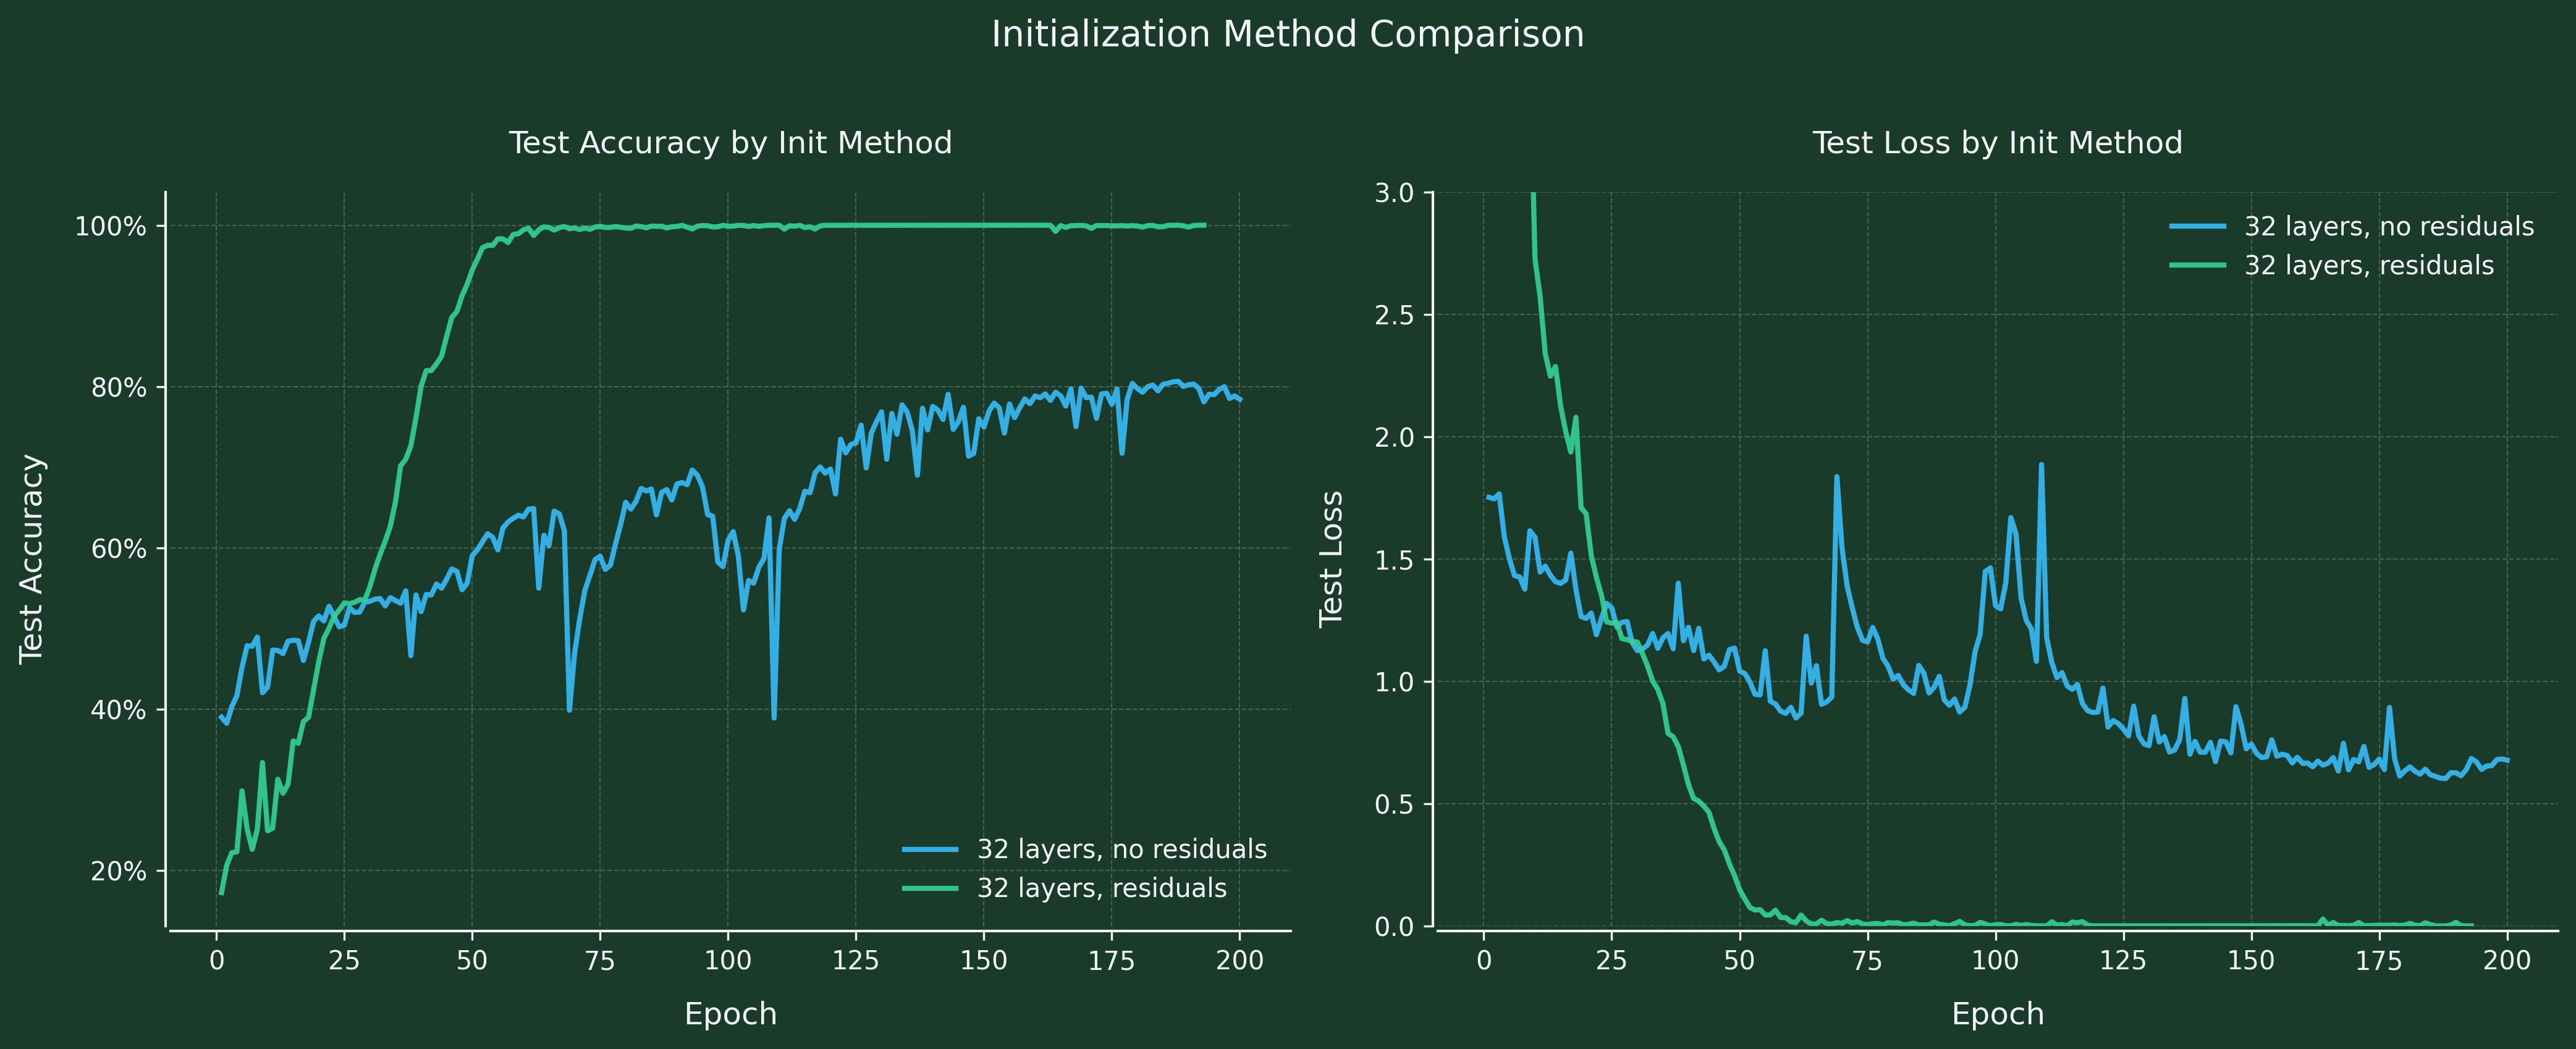


Run                  Converged Epoch     
----------------------------------------
32 layers, residuals 193                 
32 layers, no residuals Did not converge    


In [ ]:
#@title Visualize
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import logging
import matplotlib.ticker as ticker

# Suppress missing font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5B7268'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# Create figure and axis with publication-quality settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('#1A3A2A')

# Distinct bright colors for dark background (modified to keep runs distinguishable)
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    h = run["history"]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else ''

    # Plot accuracy
    axes[0].plot(h["epoch"], h["test_acc"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

    # Plot loss
    axes[1].plot(h["epoch"], h["test_loss"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

# Apply custom styling to both axes
for ax in axes:
    ax.set_facecolor('#1A3A2A')
    ax.set_xlabel('Epoch', fontsize=12, labelpad=10, color='#F1F5F9')

    # Force integer epochs
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Add grid
    ax.grid(axis='both', alpha=0.7, color='#5B7268', linestyle='--', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_color('#F1F5F9')
    ax.spines['left'].set_color('#F1F5F9')

    # Adjust spine positions
    ax.spines['left'].set_position(('outward', 2))
    ax.spines['bottom'].set_position(('outward', 2))

    # Add legend
    ax.legend(frameon=False, fontsize=10)

# Specific titles and labels
axes[0].set_ylabel('Test Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
axes[0].set_title('Test Accuracy by Init Method', color='#F1F5F9', pad=15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

axes[1].set_ylabel('Test Loss', fontsize=12, color='#F1F5F9', labelpad=10)
axes[1].set_title('Test Loss by Init Method', color='#F1F5F9', pad=15)
axes[1].set_yscale('linear')
axes[1].set_ylim(top=3.0)
axes[1].set_ylim(bottom=0.0)
axes[1].yaxis.set_major_formatter(ticker.ScalarFormatter())

# Global title
plt.suptitle("Initialization Method Comparison", fontsize=14, y=1.02, color='#F1F5F9')

# Tight layout
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Run':<20s} {'Converged Epoch':<20s}")
print("-" * 40)
for run in sorted(all_runs, key=lambda x: (x['converged_epoch'] is None, x['converged_epoch'])):
    ep = run["converged_epoch"]
    print(f"{run['name']:<20s} {str(ep) if ep else 'Did not converge':<20s}")

In [ ]:
#@title smoke test helpers

import pandas as pd
from IPython.display import HTML
import random
import numpy as np
import torch

def generate_prediction_table(num_rows=10):
    html_output = []
    html_output.append("<table style='width:100%; border-collapse: collapse; text-align: center;'>")
    html_output.append("<thead><tr style='background-color:#f2f2f2;'>")
    html_output.append("<th style='padding: 8px; border: 1px solid #ddd;'>A</th>")
    html_output.append("<th style='padding: 8px; border: 1px solid #ddd;'>B</th>")
    html_output.append("<th style='padding: 8px; border: 1px solid #ddd;'>C</th>")
    html_output.append("<th style='padding: 8px; border: 1px solid #ddd;'>Math Formula</th>")
    html_output.append("<th style='padding: 8px; border: 1px solid #ddd;'>Model Answer</th>")
    html_output.append("</tr></thead><tbody>")

    model.eval()
    # Dynamically find the input dimension expected by the model
    c_classes = model.proj_in.in_features - 200

    for _ in range(num_rows):
        # C is 1 to 19 inclusive
        a_rand = random.randint(0, 99)
        b_rand = random.randint(0, 99)
        c_rand = random.randint(1, 19)

        math_result = (a_rand * b_rand) % c_rand
        math_formula_str = f"({a_rand} * {b_rand}) % {c_rand}"

        # Encoding: c_rand-1 ensures correct index
        x_input = np.concatenate([
            one_hot(a_rand, num_classes=100),
            one_hot(b_rand, num_classes=100),
            one_hot(c_rand - 1, num_classes=c_classes)
        ])

        x_input_tensor = torch.tensor(x_input, dtype=torch.float32).to(device).unsqueeze(0)

        with torch.no_grad():
            logits = model(x_input_tensor)
            predicted_class = logits.argmax(dim=1).item()

        is_correct = (predicted_class == math_result)
        model_answer_style = "background-color:#e6ffe6;" if is_correct else "background-color:#ffe6e6;"

        html_output.append(f"<tr>")
        html_output.append(f"<td style='padding: 8px; border: 1px solid #ddd;'>{a_rand}</td>")
        html_output.append(f"<td style='padding: 8px; border: 1px solid #ddd;'>{b_rand}</td>")
        html_output.append(f"<td style='padding: 8px; border: 1px solid #ddd;'>{c_rand}</td>")
        html_output.append(f"<td style='padding: 8px; border: 1px solid #ddd;'>{math_formula_str}</td>")
        html_output.append(f"<td style='padding: 8px; border: 1px solid #ddd; {model_answer_style}'>{predicted_class}</td>")
        html_output.append(f"</tr>")

    html_output.append("</tbody></table>")
    display(HTML("".join(html_output)))

generate_prediction_table()


A,B,C,Math Formula,Model Answer
1,87,4,(1 * 87) % 4,3
87,68,9,(87 * 68) % 9,3
98,82,11,(98 * 82) % 11,6
14,37,14,(14 * 37) % 14,0
20,58,1,(20 * 58) % 1,0
92,92,9,(92 * 92) % 9,4
64,97,6,(64 * 97) % 6,4
64,13,10,(64 * 13) % 10,2
81,64,7,(81 * 64) % 7,4
19,47,6,(19 * 47) % 6,5


# 5) Activation values visualized

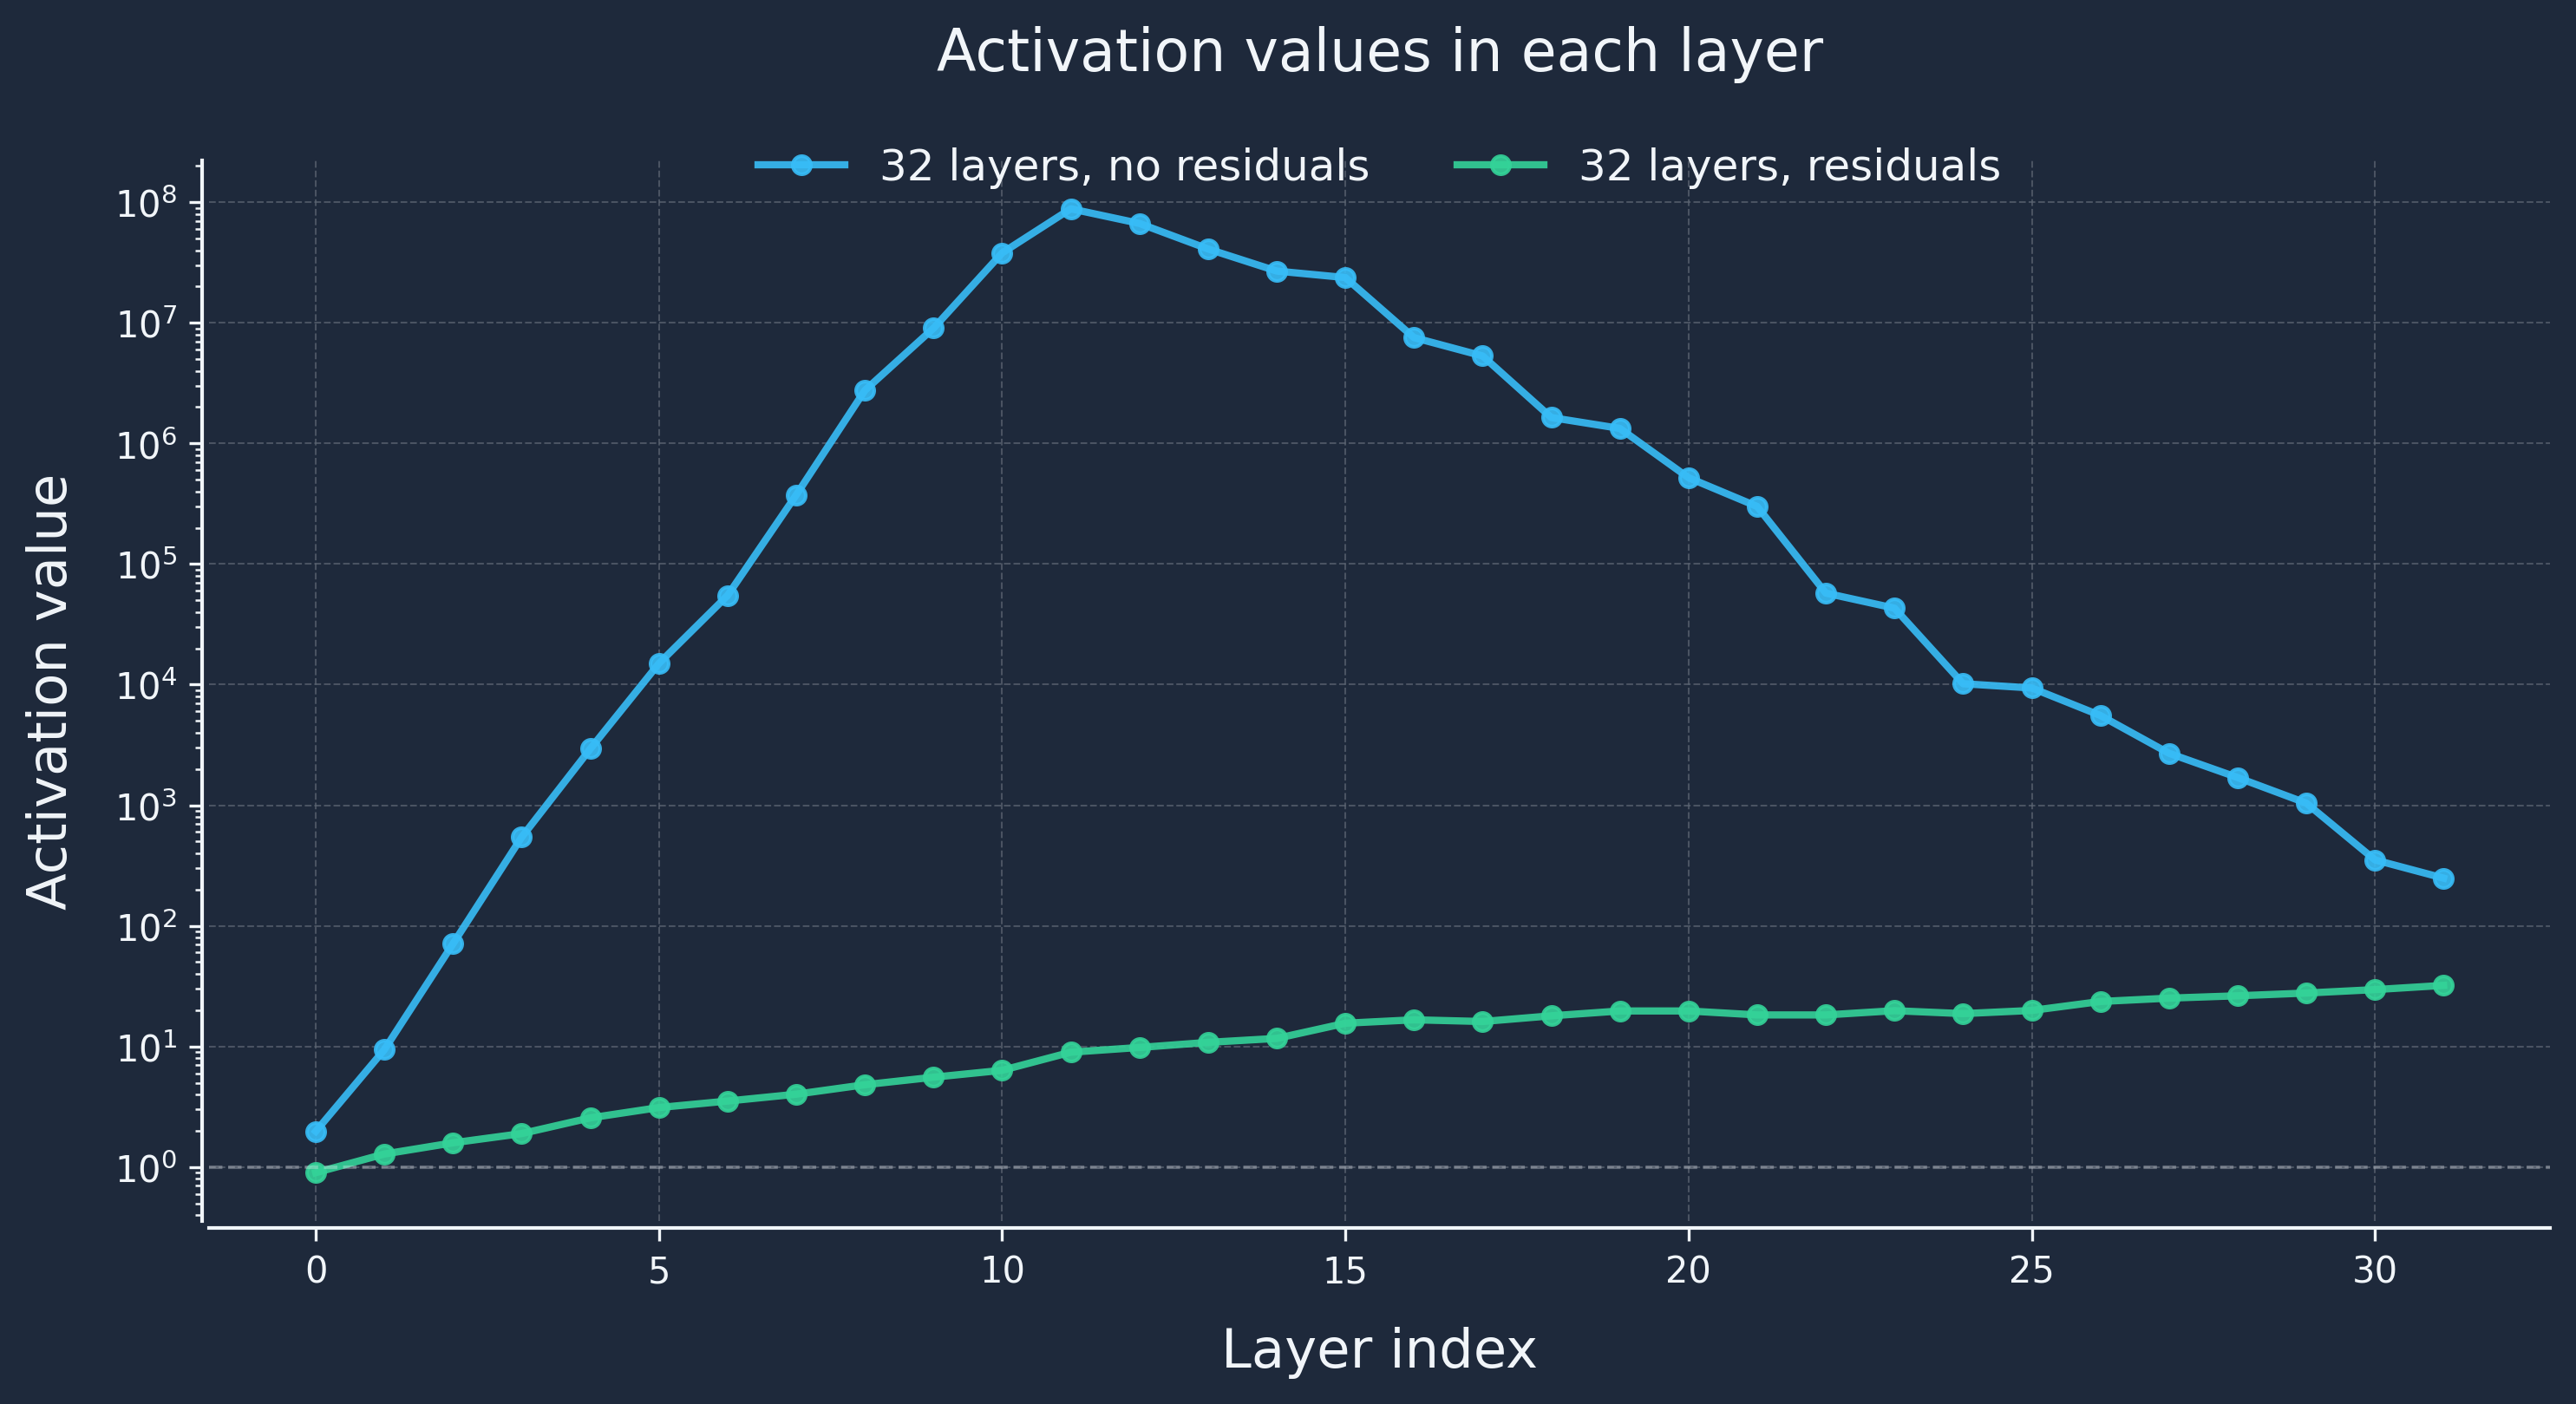

In [ ]:
#@title Visualize the activation values at each layer
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import torch

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5D6674'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# ── Signal survival per layer (post-hoc) ──
xb, yb = next(iter(test_loader))

# Create figure and axis with publication-quality settings
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
fig.patch.set_facecolor('#1E293B')
ax.set_facecolor('#1E293B')

# Define distinct bright colors instead of the same blue, so lines are distinguishable
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    model = run["model"].eval()
    if hasattr(model, "_orig_mod"):
        model = model._orig_mod

    magnitudes = []

    handles = []
    def make_hook(store):
        def hook(module, input, output):
            store.append(output.detach().abs().mean().item())
        return hook

    for block in model.layers:
        m = []
        magnitudes.append(m)
        handles.append(block.register_forward_hook(make_hook(m)))

    with torch.no_grad():
        model(xb)

    for h in handles:
        h.remove()

    layer_means = [m[0] for m in magnitudes]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else 'o'

    ax.plot(range(len(layer_means)), layer_means,
           color=colors[idx % len(colors)],
           linewidth=2,
           linestyle=line_style,
           marker=marker_style, markersize=5,
           label=run["name"],
           alpha=0.9)

ax.set_yscale("log")
ax.axhline(y=1.0, color="#F1F5F9", linestyle="--", alpha=0.3, linewidth=1)

# Customize axis labels
ax.set_xlabel('Layer index', fontsize=15, labelpad=10, color='#F1F5F9')
ax.set_ylabel('Activation value', fontsize=15, color='#F1F5F9', labelpad=10)
ax.set_title("Activation values in each layer", fontsize=16, color='#F1F5F9', pad=25)

# Add grid
ax.grid(axis='both', alpha=0.7, color='#5D6674', linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='upper center',
         bbox_to_anchor=(0.5, 1.05),
         frameon=False, fontsize=12, ncol=3)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('#F1F5F9')
ax.spines['left'].set_color('#F1F5F9')

# Adjust spine positions
ax.spines['left'].set_position(('outward', 2))
ax.spines['bottom'].set_position(('outward', 2))

# Tight layout
plt.tight_layout()

# Display the plot
plt.show()

# 6) 72 layers, no residual

In [ ]:
assert False, "code up a DNN with 72 linear layers without using residuals"

AssertionError: code up a DNN with 72 linear layers without using residuals

In [ ]:
#@title Answer
train(run_name="72 layers, no residuals", layer_depth=72, has_residuals=False)

  🚀 Run: 72 layers, no residuals
Epoch      1 | Train loss 2.3645  acc 33.8% | Test loss 2.3707  acc 33.6%
Epoch      2 | Train loss 2.3528  acc 33.8% | Test loss 2.3581  acc 33.6%
Epoch      3 | Train loss 2.3542  acc 33.8% | Test loss 2.3596  acc 33.6%
Epoch      4 | Train loss 2.3548  acc 33.8% | Test loss 2.3602  acc 33.6%
Epoch      5 | Train loss 2.3519  acc 33.8% | Test loss 2.3573  acc 33.6%
Epoch      6 | Train loss 2.3517  acc 33.8% | Test loss 2.3570  acc 33.6%
Epoch      7 | Train loss 2.3520  acc 33.8% | Test loss 2.3568  acc 33.6%
Epoch      8 | Train loss 2.3515  acc 33.8% | Test loss 2.3565  acc 33.6%
Epoch      9 | Train loss 2.3517  acc 33.8% | Test loss 2.3567  acc 33.6%
Epoch     10 | Train loss 2.3514  acc 33.8% | Test loss 2.3567  acc 33.6%
Epoch     11 | Train loss 2.3521  acc 33.8% | Test loss 2.3579  acc 33.6%
Epoch     12 | Train loss 2.3514  acc 33.8% | Test loss 2.3569  acc 33.6%
Epoch     13 | Train loss 2.3517  acc 33.8% | Test loss 2.3571  acc 33.6%
Epoch

# 7) DNN with 16 layers of 2xFFN growing & shrinking & ReLU

In [ ]:
assert False, "code up a DNN that has 16 layers of 2 FFN layers (growing and shrinking) alongside ReLU"

AssertionError: code up a DNN that has 32 layers of 2 FFN layers (growing and shrinking) alongside ReLU

In [ ]:
#@title Answer - DNN definition

class DNN(nn.Module):
    def __init__(self, input_dim=220,
                 output_dim=20, hidden_dim=128,
                 layer_depth=16, has_residuals=False):
        super().__init__()
        self.has_residuals = has_residuals
        self.proj_in = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(layer_depth):
            self.layers.append(
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim * 2),
                    nn.ReLU(),
                    nn.Linear(hidden_dim * 2, hidden_dim))
                )
        self.proj_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.proj_in(x))
        for layer in self.layers:
            if self.has_residuals:
                x = x + layer(x)
            else:
                x = layer(x)
        return self.proj_out(x)

model = DNN().to(device)
print(model)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Per-layer shapes:")
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"  {name:30s}  {str(list(param.shape)):>15s}  ({param.numel():>6,} params)")

DNN(
  (proj_in): Linear(in_features=220, out_features=128, bias=True)
  (layers): ModuleList(
    (0-15): 16 x Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (proj_out): Linear(in_features=128, out_features=20, bias=True)
)
Total parameters: 1,085,588
Per-layer shapes:
  proj_in.weight                       [128, 220]  (28,160 params)
  layers.0.0.weight                    [256, 128]  (32,768 params)
  layers.0.2.weight                    [128, 256]  (32,768 params)
  layers.1.0.weight                    [256, 128]  (32,768 params)
  layers.1.2.weight                    [128, 256]  (32,768 params)
  layers.2.0.weight                    [256, 128]  (32,768 params)
  layers.2.2.weight                    [128, 256]  (32,768 params)
  layers.3.0.weight                    [256, 128]  (32,768 params)
  layers.3.2.weight                    [128, 256]  (32,768 params)
  l

In [ ]:
#@title answer - training
train(run_name="16 layers of 2x growing & shrinking FFN, no residuals",
      layer_depth=16,
      has_residuals=False)

  🚀 Run: 16 layers of 2x growing & shrinking FFN, no residuals
Epoch      1 | Train loss 1.9689  acc 34.3% | Test loss 1.9832  acc 34.0%
Epoch      2 | Train loss 1.5008  acc 44.6% | Test loss 1.5116  acc 44.1%
Epoch      3 | Train loss 1.1512  acc 53.2% | Test loss 1.1581  acc 53.3%
Epoch      4 | Train loss 1.0720  acc 54.0% | Test loss 1.0788  acc 53.6%
Epoch      5 | Train loss 1.0424  acc 54.6% | Test loss 1.0477  acc 54.1%
Epoch      6 | Train loss 1.0600  acc 54.5% | Test loss 1.0622  acc 54.1%
Epoch      7 | Train loss 1.0739  acc 53.9% | Test loss 1.0789  acc 53.8%
Epoch      8 | Train loss 1.0367  acc 54.6% | Test loss 1.0378  acc 54.4%
Epoch      9 | Train loss 1.0549  acc 54.5% | Test loss 1.0579  acc 54.2%
Epoch     10 | Train loss 1.2756  acc 51.0% | Test loss 1.2821  acc 51.1%
Epoch     11 | Train loss 1.1979  acc 51.3% | Test loss 1.1992  acc 51.2%
Epoch     12 | Train loss 1.1864  acc 51.6% | Test loss 1.1883  acc 51.7%
Epoch     13 | Train loss 1.1477  acc 52.0% | Tes

In [ ]:
train(run_name="16 layers of 2x growing & shrinking FFN, with residuals", layer_depth=16, has_residuals=True)


  🚀 Run: 16 layers of 2x growing & shrinking FFN, with residuals
Epoch      1 | Train loss 2.4953  acc 31.3% | Test loss 2.5443  acc 30.8%
Epoch      2 | Train loss 2.1924  acc 31.1% | Test loss 2.2337  acc 30.6%
Epoch      3 | Train loss 2.0495  acc 33.0% | Test loss 2.0996  acc 32.0%
Epoch      4 | Train loss 1.9512  acc 35.0% | Test loss 2.0052  acc 33.7%
Epoch      5 | Train loss 1.8381  acc 37.0% | Test loss 1.8986  acc 35.1%
Epoch      6 | Train loss 1.6985  acc 41.0% | Test loss 1.7757  acc 39.0%
Epoch      7 | Train loss 1.4856  acc 46.7% | Test loss 1.5592  acc 44.6%
Epoch      8 | Train loss 1.3069  acc 50.9% | Test loss 1.3864  acc 48.8%
Epoch      9 | Train loss 1.1300  acc 54.5% | Test loss 1.1892  acc 52.6%
Epoch     10 | Train loss 1.0928  acc 55.1% | Test loss 1.1373  acc 53.4%
Epoch     11 | Train loss 1.0778  acc 55.4% | Test loss 1.1204  acc 53.6%
Epoch     12 | Train loss 1.0782  acc 55.4% | Test loss 1.1184  acc 53.4%
Epoch     13 | Train loss 1.0608  acc 55.4% | T

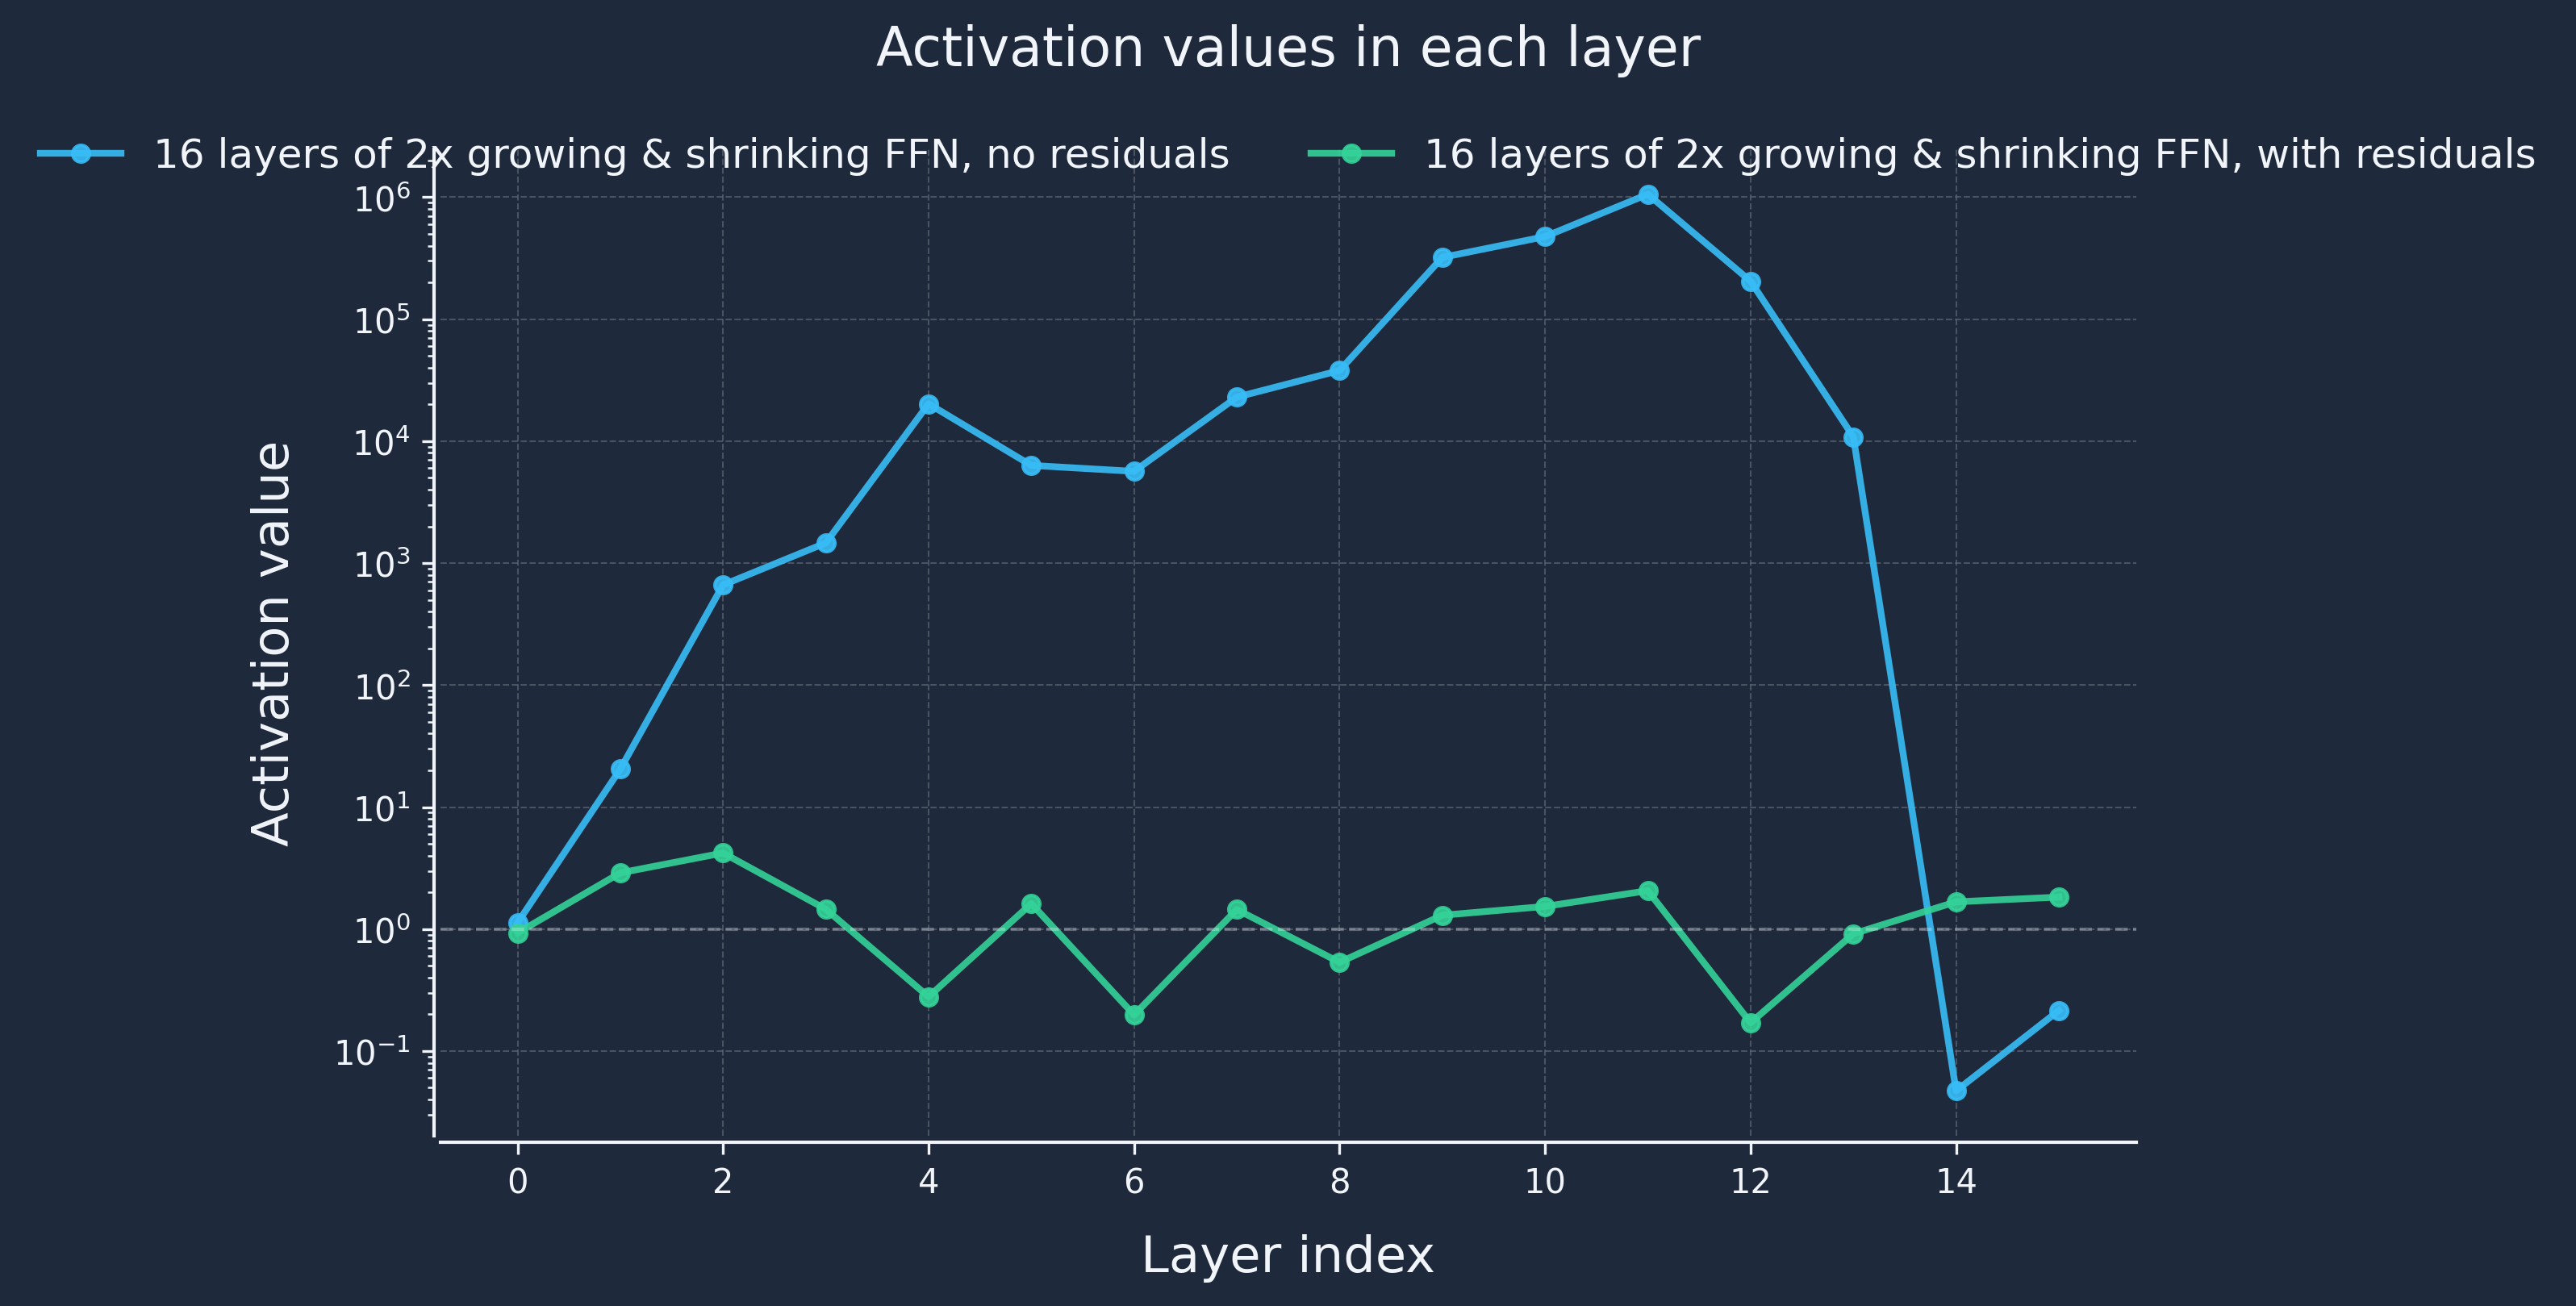

In [ ]:
#@title visualize activation values over layers
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import torch

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5D6674'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# ── Signal survival per layer (post-hoc) ──
xb, yb = next(iter(test_loader))

# Create figure and axis with publication-quality settings
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
fig.patch.set_facecolor('#1E293B')
ax.set_facecolor('#1E293B')

# Define distinct bright colors instead of the same blue, so lines are distinguishable
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    model = run["model"].eval()
    if hasattr(model, "_orig_mod"):
        model = model._orig_mod

    magnitudes = []

    handles = []
    def make_hook(store):
        def hook(module, input, output):
            store.append(output.detach().abs().mean().item())
        return hook

    for block in model.layers:
        m = []
        magnitudes.append(m)
        handles.append(block.register_forward_hook(make_hook(m)))

    with torch.no_grad():
        model(xb)

    for h in handles:
        h.remove()

    layer_means = [m[0] for m in magnitudes]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else 'o'

    ax.plot(range(len(layer_means)), layer_means,
           color=colors[idx % len(colors)],
           linewidth=2,
           linestyle=line_style,
           marker=marker_style, markersize=5,
           label=run["name"],
           alpha=0.9)

ax.set_yscale("log")
ax.axhline(y=1.0, color="#F1F5F9", linestyle="--", alpha=0.3, linewidth=1)

# Customize axis labels
ax.set_xlabel('Layer index', fontsize=15, labelpad=10, color='#F1F5F9')
ax.set_ylabel('Activation value', fontsize=15, color='#F1F5F9', labelpad=10)
ax.set_title("Activation values in each layer", fontsize=16, color='#F1F5F9', pad=25)

# Add grid
ax.grid(axis='both', alpha=0.7, color='#5D6674', linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='upper center',
         bbox_to_anchor=(0.5, 1.05),
         frameon=False, fontsize=12, ncol=3)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('#F1F5F9')
ax.spines['left'].set_color('#F1F5F9')

# Adjust spine positions
ax.spines['left'].set_position(('outward', 2))
ax.spines['bottom'].set_position(('outward', 2))

# Tight layout
plt.tight_layout()

# Display the plot
plt.show()

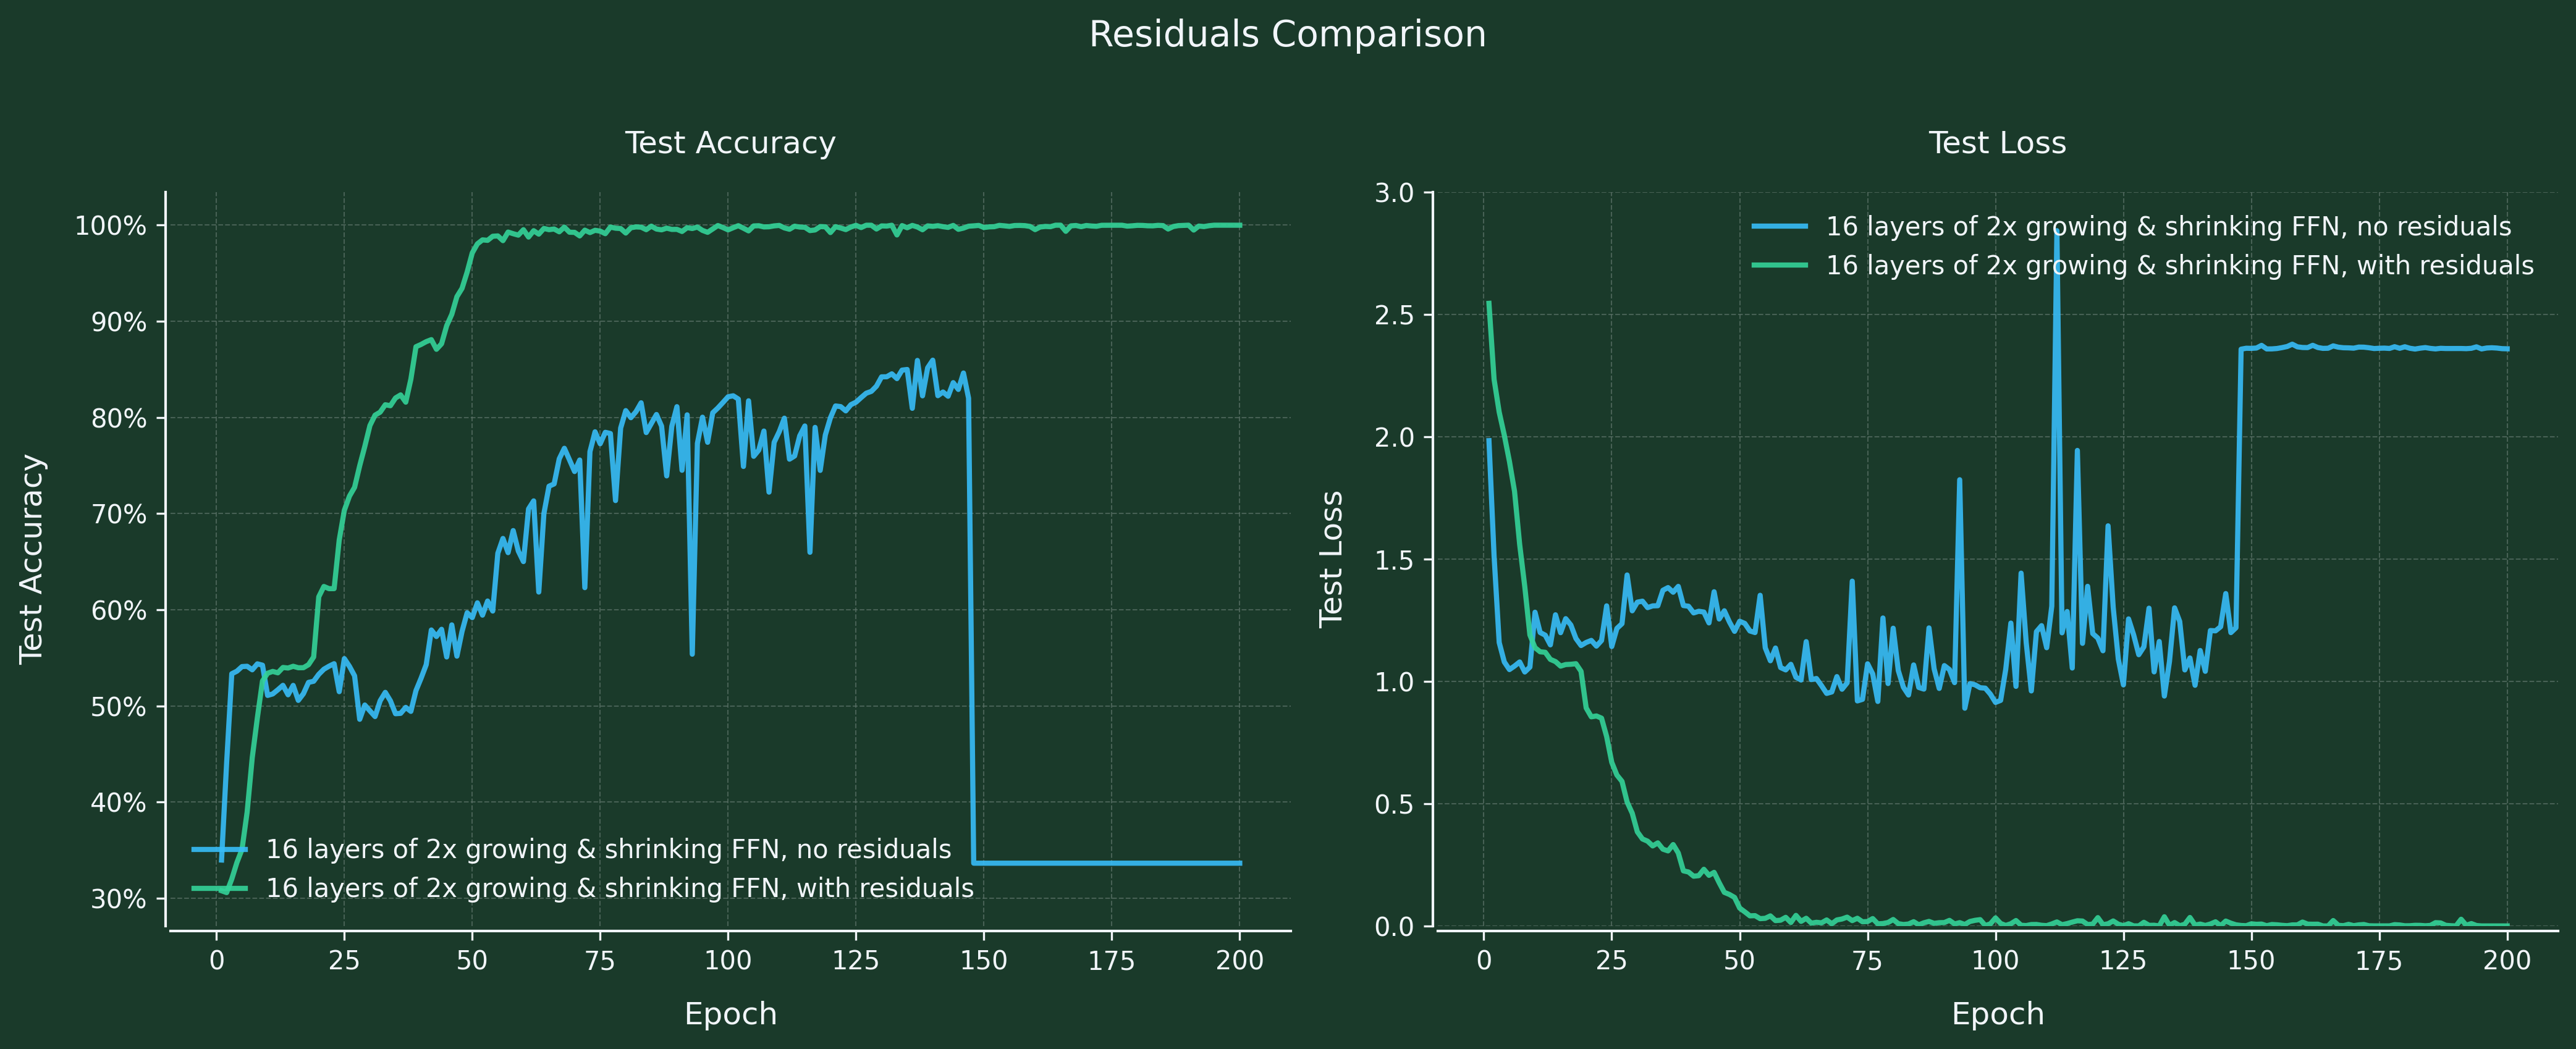


Run                  Converged Epoch     
----------------------------------------
16 layers of 2x growing & shrinking FFN, no residuals Did not converge    
16 layers of 2x growing & shrinking FFN, with residuals Did not converge    


In [ ]:
#@title Visualize results
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import logging
import matplotlib.ticker as ticker

# Suppress missing font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5B7268'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# Create figure and axis with publication-quality settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('#1A3A2A')

# Distinct bright colors for dark background (modified to keep runs distinguishable)
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    h = run["history"]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else ''

    # Plot accuracy
    axes[0].plot(h["epoch"], h["test_acc"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

    # Plot loss
    axes[1].plot(h["epoch"], h["test_loss"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

# Apply custom styling to both axes
for ax in axes:
    ax.set_facecolor('#1A3A2A')
    ax.set_xlabel('Epoch', fontsize=12, labelpad=10, color='#F1F5F9')

    # Force integer epochs
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Add grid
    ax.grid(axis='both', alpha=0.7, color='#5B7268', linestyle='--', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_color('#F1F5F9')
    ax.spines['left'].set_color('#F1F5F9')

    # Adjust spine positions
    ax.spines['left'].set_position(('outward', 2))
    ax.spines['bottom'].set_position(('outward', 2))

    # Add legend
    ax.legend(frameon=False, fontsize=10)

# Specific titles and labels
axes[0].set_ylabel('Test Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
axes[0].set_title('Test Accuracy', color='#F1F5F9', pad=15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

axes[1].set_ylabel('Test Loss', fontsize=12, color='#F1F5F9', labelpad=10)
axes[1].set_title('Test Loss', color='#F1F5F9', pad=15)
axes[1].set_yscale('linear')
axes[1].set_ylim(top=3.0)
axes[1].set_ylim(bottom=0.0)
axes[1].yaxis.set_major_formatter(ticker.ScalarFormatter())

# Global title
plt.suptitle("Residuals Comparison", fontsize=14, y=1.02, color='#F1F5F9')

# Tight layout
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Run':<20s} {'Converged Epoch':<20s}")
print("-" * 40)
for run in sorted(all_runs, key=lambda x: (x['converged_epoch'] is None, x['converged_epoch'])):
    ep = run["converged_epoch"]
    print(f"{run['name']:<20s} {str(ep) if ep else 'Did not converge':<20s}")